In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import os
import sys
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score

print(sys.version_info)
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

seed = 42
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


sys.version_info(major=3, minor=14, micro=2, releaselevel='final', serial=0)
cuda:0


In [2]:
# 自动判断路径逻辑
if Path("trainLables.csv").exists():
    BASE_DIR = Path(".")
    csv_name = "trainLables.csv"
elif Path("cifar-10/trainLables.csv").exists():
    BASE_DIR = Path("cifar-10")
    csv_name = "trainLables.csv"
elif Path("trainLabels.csv").exists():
    BASE_DIR = Path(".")
    csv_name = "trainLabels.csv"
elif Path("cifar-10/trainLabels.csv").exists():
    BASE_DIR = Path("cifar-10")
    csv_name = "trainLabels.csv"
else:
    raise FileNotFoundError("无法找到 trainLabels.csv")

DATA_DIR = BASE_DIR
train_lables_file = DATA_DIR / csv_name
test_csv_file = DATA_DIR / "sampleSubmission.csv"
train_folder = DATA_DIR / "train"
test_folder = DATA_DIR / "test"

def parse_csv_file(filepath, folder):
    results = []
    with open(filepath, 'r') as f:
        lines = f.readlines()[1:]
    for line in lines:
        image_id, label_str = line.strip('\n').split(',')
        image_full_path = folder / f"{image_id}.png"
        results.append((image_full_path, label_str))
    return results

train_labels_info = parse_csv_file(train_lables_file, train_folder)
test_csv_info = parse_csv_file(test_csv_file, test_folder)

class_names = sorted({label for _, label in train_labels_info})
print(f"classes ({len(class_names)}): {class_names}")


classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
train_df = pd.DataFrame(train_labels_info[0:45000])
valid_df = pd.DataFrame(train_labels_info[45000:])
test_df = pd.DataFrame(test_csv_info)

train_df.columns = ['filepath', 'class']
valid_df.columns = ['filepath', 'class']
test_df.columns = ['filepath', 'class']


In [4]:
class Cifar10Dataset(Dataset):
    df_map = {
        "train": train_df,
        "eval": valid_df,
        "test": test_df
    }
    label_to_idx = {label: idx for idx, label in enumerate(class_names)}
    idx_to_label = {idx: label for idx, label in enumerate(class_names)}

    def __init__(self, mode, transform=None):
        self.df = self.df_map.get(mode, None)
        self.transform = transform

        print(f"Loading {mode} data into memory...")
        self.images = []
        self.labels = []

        # 预加载所有图片到内存
        for idx in tqdm(range(len(self.df)), desc=f"Loading {mode}"):
            img_path, label = self.df.iloc[idx]
            img = Image.open(img_path).convert('RGB')
            self.images.append(img)
            self.labels.append(self.label_to_idx[label])

    def __getitem__(self, index):
        img = self.images[index]
        label = self.labels[index]

        if self.transform:
            img = self.transform(img)

        return img, label

    def __len__(self):
        return len(self.images)

mean, std = [0.4914, 0.4822, 0.4465], [0.247, 0.243, 0.261]

transforms_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

transforms_eval = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

train_ds = Cifar10Dataset("train", transforms_train)
eval_ds = Cifar10Dataset("eval", transforms_eval)


Loading train data into memory...


Loading train:   0%|          | 0/45000 [00:00<?, ?it/s]

Loading eval data into memory...


Loading eval:   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
# Windows 下 num_workers > 0 容易导致死锁，特别是配合 Jupyter Notebook 和内存预加载时
# 由于数据已经在内存中，num_workers=0 (主进程读取) 速度也非常快，且最稳定
batch_size = 512
num_workers = 0

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
eval_dl = DataLoader(
    eval_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)


In [6]:
class VGG(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )
        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [7]:
def _accuracy_from_logits(logits, labels):
    preds = logits.argmax(dim=-1)
    return (preds == labels).float().mean().item()

@torch.no_grad()
def evaluating(model, dataloader, loss_fct):
    loss_list = []
    correct = 0
    total = 0
    for datas, labels in dataloader:
        datas = datas.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(datas)
        loss = loss_fct(logits, labels)
        loss_list.append(loss.item())

        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.numel()

    acc = correct / max(total, 1)
    return np.mean(loss_list), acc


In [8]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_step=5000, save_best_only=True):
        self.save_dir = save_dir
        self.save_step = save_step
        self.save_best_only = save_best_only
        self.best_metrics = -1

        if not os.path.exists(self.save_dir):
            os.mkdir(self.save_dir)

    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0:
            return

        if self.save_best_only:
            assert metric is not None
            if metric >= self.best_metrics:
                torch.save(state_dict, os.path.join(self.save_dir, "best.ckpt"))
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt"))


In [9]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_metric = -1
        self.counter = 0

    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            self.counter = 0
        else:
            self.counter += 1

    @property
    def early_stop(self):
        return self.counter >= self.patience


In [10]:
def training(
    model,
    train_loader,
    val_loader,
    epoch,
    loss_fct,
    optimizer,
    scaler,
    save_ckpt_callback=None,
    early_stop_callback=None,
    eval_step=500,
    ):
    record_dict = {
        "train": [],
        "val": []
    }

    global_step = 0
    model.train()
    with tqdm(total=epoch * len(train_loader)) as pbar:
        for epoch_id in range(epoch):
            for datas, labels in train_loader:
                datas = datas.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)
                with torch.amp.autocast("cuda", enabled=device.type == "cuda"):
                    logits = model(datas)
                    loss = loss_fct(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

                acc = _accuracy_from_logits(logits, labels)
                loss = loss.detach().cpu().item()

                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                })

                if global_step % eval_step == 0:
                    model.eval()
                    val_loss, val_acc = evaluating(model, val_loader, loss_fct)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train()

                    if save_ckpt_callback is not None:
                        save_ckpt_callback(global_step, model.state_dict(), metric=val_acc)

                    if early_stop_callback is not None:
                        early_stop_callback(val_acc)
                        if early_stop_callback.early_stop:
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1
                pbar.update(1)
                pbar.set_postfix({"epoch": epoch_id})

    return record_dict

epoch = 50
model = VGG(num_classes=10)
model = model.to(device=device, memory_format=torch.channels_last)

loss_fct = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")

if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")
save_ckpt_callback = SaveCheckpointsCallback("checkpoints/vgg", save_step=len(train_dl), save_best_only=True)
early_stop_callback = EarlyStopCallback(patience=5)

model = model.to(device)
record = training(
    model,
    train_dl,
    eval_dl,
    epoch,
    loss_fct,
    optimizer,
    scaler,
    save_ckpt_callback=save_ckpt_callback,
    early_stop_callback=early_stop_callback,
    eval_step=len(train_dl) * 2
    )


  0%|          | 0/4400 [00:00<?, ?it/s]

Early stop at epoch 36 / global_step 3168


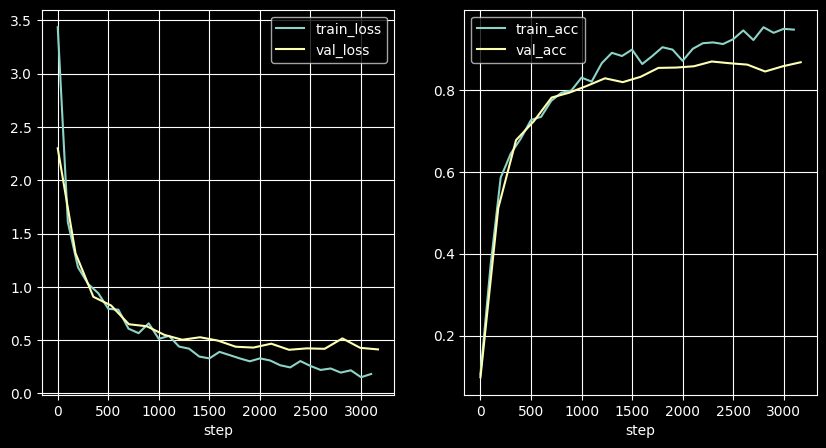

In [11]:
def plot_learning_curves(record_dict, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")

    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for idx, item in enumerate(train_df.columns):
        axs[idx].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[idx].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[idx].grid()
        axs[idx].legend()
        axs[idx].set_xlabel("step")

    plt.show()

plot_learning_curves(record, sample_step=100)


In [12]:
model.load_state_dict(torch.load("checkpoints/vgg/best.ckpt", map_location="cpu"))
model = model.to(device=device, memory_format=torch.channels_last)
model.eval()
loss, acc = evaluating(model, eval_dl, loss_fct)
print(f"loss:     {loss:.4f}\naccuracy: {acc:.4f}")


loss:     0.4096
accuracy: 0.8694


本次训练依然出现死锁，故采用单线程

采用vgg论文的11层结构，训练了50轮，最终在验证集上取得了约0.86的准确率。训练过程中使用了Early Stopping机制，在验证集准确率连续5次没有提升超过0.01时提前停止训练。最终模型保存在 checkpoints/vgg/best.ckpt 中，可以通过加载该文件来使用训练好的模型进行推理或继续训练。